<h2>Cartesian Coordinates To Geodetic Coordinates<h2>

In [18]:
import pandas as pd
from math import *
import numpy as np
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv("igs_coordinates.csv")

In [20]:
a = 6378137  
b = 6356752.3141
e = sqrt((a**2 - b**2) / (a**2))
eprim = e**2 / (1-e**2)

xrcv = 4514721.9625
yrcv = 3133507.7815
zrcv = 3228024.6073
p = sqrt(xrcv**2 + yrcv**2)
theta = atan((zrcv * a) / (p * b))
phircv = atan2(zrcv + (eprim * b * sin(theta)**3), (p - (e**2 * a * cos(theta)**3)))
landarcv = atan(yrcv / xrcv)
east = (-sin(landarcv), cos(landarcv), 0)
n = (-cos(landarcv)*sin(phircv), -sin(landarcv)*sin(phircv), cos(phircv))
u = (cos(landarcv)*cos(phircv), sin(landarcv)*cos(phircv), sin(phircv))

In [21]:
x = np.array(data.X)
y = np.array(data.Y)
z = np.array(data.Z)

In [22]:
landas = [np.arctan2(y[r], x[r]) for r in range(len(data.X))]
data["Landa"] = landas

In [23]:
def N(phi):
    return ((a) / ((1 - (e**2 * (np.sin(phi)**2)))) ** (1 / 2))

def phi_calculator(x, y, z, N_val, phi_val):
    return np.arctan2(z + e**2* N_val * np.sin(phi_val), (np.sqrt(x**2 + y**2)))

In [24]:
p = np.sqrt(x**2 + y**2)
phi_0s = np.arctan2(z, p*(1-e**2))


Ns = np.array([N(phi_0) for phi_0 in phi_0s])
phi_news = np.array([phi_calculator(x[r], y[r], z[r], Ns[r], phi_0s[r]) for r in range(len(x))])
epsilon = 0.0000001
error = 10
np.array(phi_news)

while error > epsilon:
    phi_olds = phi_news.copy()
    Ns = np.array([N(phi_old) for phi_old in phi_olds])
    phi_news = np.array([phi_calculator(x[r], y[r], z[r], Ns[r], phi_olds[r]) for r in range(len(x))])
    error = np.linalg.norm((phi_news - phi_olds))


In [25]:
data["Phi"] = phi_news
phis = data.Phi.values  
landas = data.Landa.values
Ns = N(phis) 

h1 = ((np.sqrt(x**2 + y**2)) / np.cos(phis)) - Ns # when phi isn't 90 degrees
h2 = (z / (np.sin(phis)) - (Ns * (1 - e**2))) # when phi is 90 degrees

<h2>Geodetic Coordinates To Cartesian<h2>

In [26]:
x_cart = (Ns + h1) * np.cos(phis) * np.cos(data.Landa)
y_cart = (Ns + h1) * np.cos(phis) * np.sin(data.Landa)
z_cart = (Ns * (1 - e**2) + h1) * np.sin(phis) # delete h if it was wrong

<h2>Cartesian To Geodetic<h2>

In [27]:
landas_cart = [np.arctan2(y_cart[r], x_cart[r]) for r in range(len(x_cart))]

In [28]:
p_cart = np.sqrt(x_cart**2 + y_cart**2)
phi_0s_cart = np.arctan2(z_cart, p_cart*(1-e**2))

Ns_cart = np.array([N(phi_0) for phi_0 in phi_0s_cart])
phi_news_cart = np.array([phi_calculator(x_cart[r], y_cart[r], z_cart[r], Ns_cart[r], phi_0s_cart[r]) for r in range(len(x_cart))])
epsilon_cart = 0.0000001
iteration_cart = 0
error_cart = 1
np.array(phi_news_cart)

while error_cart > epsilon_cart:
    phi_olds_cart = phi_news_cart.copy()
    Ns_cart = np.array([N(phi_old_cart) for phi_old_cart in phi_olds_cart])
    phi_news_cart = np.array([phi_calculator(x_cart[r], y_cart[r], z_cart[r], Ns_cart[r], phi_olds_cart[r]) for r in range(len(x_cart))])
    error_cart = np.linalg.norm((phi_news_cart - phi_olds_cart))

    iteration_cart += 1
    # print(f"iteration number = {iteration_cart}")


In [29]:
phis_cart = phi_news_cart
Ns_cart = N(phis_cart) 

h1_cart = ((np.sqrt(x_cart**2 + y_cart**2)) / np.cos(phis_cart)) - Ns_cart # when phi isn't 90 degrees
h2_cart = (z_cart / (np.sin(phis_cart)) - (Ns_cart * (1 - e**2))) # when phi is 90 degrees

<h2>Comparisons & Visualizations<h2>

In [30]:
differences_phi   = abs(phis - phis_cart) 
differences_landa = abs(landas - landas_cart) 
differences_h1    = abs(h1 - h1_cart) 
differences_h2    = abs(h2 - h2_cart) 

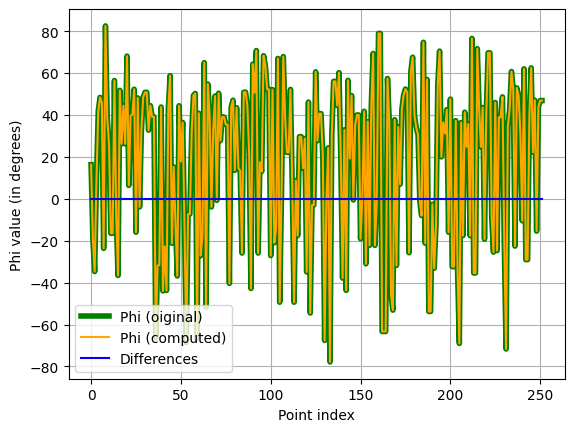

In [31]:
plt.figure()
plt.plot(np.rad2deg(phis), label='Phi (oiginal)', color='green', linewidth=4)
plt.plot(np.rad2deg(phis_cart), label='Phi (computed)', color='orange')
plt.plot(np.rad2deg(differences_phi), label='Differences', color='blue')

plt.xlabel('Point index')
plt.ylabel('Phi value (in degrees)')
plt.legend()
plt.grid(True)
plt.show()


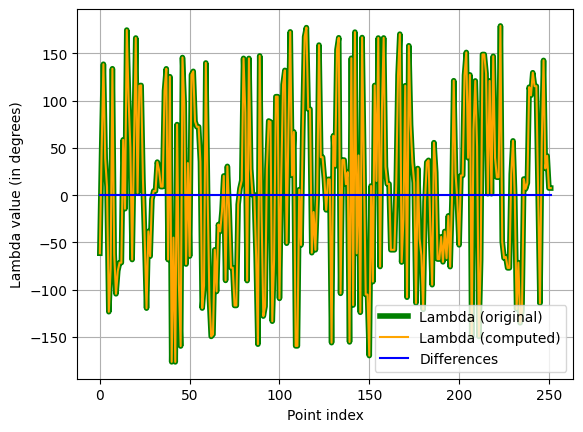

In [32]:
plt.figure()
plt.plot(np.rad2deg(landas), label='Lambda (original)', color='green', linewidth=4)
plt.plot(np.rad2deg(landas_cart), label='Lambda (computed)', color='orange')
plt.plot(np.rad2deg(differences_landa), label='Differences', color='blue')

plt.xlabel('Point index')
plt.ylabel('Lambda value (in degrees)')
plt.legend()
plt.grid(True)
plt.show()


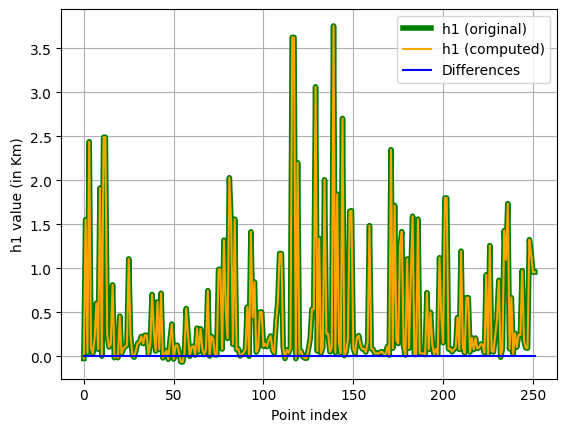

In [33]:
plt.figure()
plt.plot(h1 / 1000, label='h1 (original)', color='green', linewidth=4)
plt.plot(h1_cart / 1000, label='h1 (computed)', color='orange')
plt.plot(differences_h1 / 1000, label='Differences', color='blue')

plt.xlabel('Point index')
plt.ylabel('h1 value (in Km)')
plt.legend()
plt.grid(True)
plt.show()


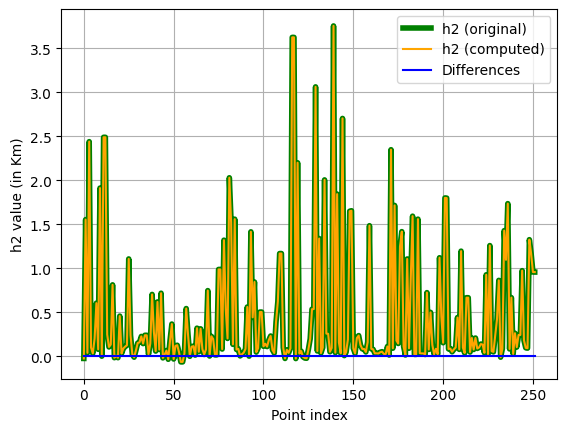

In [34]:
plt.figure()
plt.plot(h2 / 1000, label='h2 (original)', color='green', linewidth=4)
plt.plot(h2_cart / 1000, label='h2 (computed)', color='orange')
plt.plot(differences_h2 / 1000, label='Differences', color='blue')

plt.xlabel('Point index')
plt.ylabel('h2 value (in Km)')
plt.legend()
plt.grid(True)
plt.show()
